In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression.sr import TemplateConfig, PySRParams, ModelParametrizer

from sympy import Matrix, Float, preorder_traversal
from warnings import catch_warnings, simplefilter

from numpy import log
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cProfile

_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
parser = ModelParser("../MODELS/classes/reference.yaml")
model, kalman = parser.get_all()

with catch_warnings():
    # Equations in a sp.Matrix are deprecated, this is only used as a pretty print function
    simplefilter(action="ignore")
    mat = Matrix(model.equations.model)
mat

Matrix([
[                                    Eq(Pi(t), beta*Pi(t + 1) + kappa*(x(t) - z(t)))],
[                           Eq(x(t), -tau_inv*(-Pi(t + 1) + r(t)) + g(t) + x(t + 1))],
[Eq(r(t), e_r + rho_r*r(t - 1*1) + (1 - rho_r)*(psi_pi*Pi(t) + psi_x*(x(t) - z(t))))],
[                                                   Eq(g(t), e_g + rho_g*g(t - 1*1))],
[                                                   Eq(z(t), e_z + rho_z*z(t - 1*1))]])

In [3]:
fred = FRED(
    key_env=None,  # None => look for the ".env" file. If you have a custom env file, provide its path here.
    key_name="FRED_KEY",  # Name of the variable in the env file that contains the FRED API key.
)
df = fred.get_frame(
    series_ids=[
        "A939RX0Q048SBEA",  # Real GDP per Cap.
        "CPIAUCSL",  # Consumer Price Index for All Urban Consumers: All Items
        "FEDFUNDS",  # Effective Federal Funds Rate
    ],
    date_range=(
        "1955-01-01",
        "2007-10-01",
    ),  # Date range for the data ("YYYY-MM-DD" format or a pd.DatetimeIndex object)
)

gdp_q = df["A939RX0Q048SBEA"]  # already quarterly in most pulls; verify freq

cpi_q = df["CPIAUCSL"].resample("QS").mean()  # quarterly avg CPI
ffr_q = df["FEDFUNDS"].resample("QS").mean()  # quarterly avg policy rate

idx_range = pd.date_range(start="1984-01-01", end="2007-01-01", freq="QS")


df = pd.DataFrame(
    {
        "A939RX0Q048SBEA": gdp_q.reindex(idx_range),
        "CPIAUCSL": cpi_q.reindex(idx_range),
        "FEDFUNDS": ffr_q.reindex(idx_range),
    }
)

df

,A939RX0Q048SBEA,CPIAUCSL,FEDFUNDS
1984-01-01,34103.0,102.533333,9.686667
1984-04-01,34622.0,103.500000,10.556667
1984-07-01,34871.0,104.400000,11.390000
1984-10-01,35072.0,105.300000,9.266667
1985-01-01,35346.0,106.266667,8.476667
...,...,...,...
2006-01-01,54927.0,199.466667,4.456667
2006-04-01,54945.0,201.266667,4.906667
2006-07-01,54886.0,203.166667,5.246667
2006-10-01,55216.0,202.333333,5.246667


In [4]:
x_trend = HP_two_sided(log(df["A939RX0Q048SBEA"]), lamb=1600)[
    0
]  # returns (trend, cycle)
x = (
    log(df["A939RX0Q048SBEA"]) - x_trend
) * 100  # HP detrended quarterly log output gap


inf_lvl = annualized_log_percent(df["CPIAUCSL"], periods_per_year=4)
rate_lvl = df["FEDFUNDS"]

r_ss = model.calibration.parameters["r_star"]
pi_ss = model.calibration.parameters["pi_star"]

rate = (rate_lvl - (r_ss + pi_ss)) / 4  # gap to steady state
inf = (inf_lvl - pi_ss) / 4  # gap to steady state

df_model_units = pd.DataFrame(
    {
        "r": rate,
        "Pi": inf,
        "x": x,
    }
).dropna()

observed = pd.DataFrame(
    {
        "OutGap": df_model_units["x"],
        "Infl": inf_lvl[df_model_units.index],
        "Rate": rate_lvl[df_model_units.index],
    }
)
observed.index = df_model_units.index

In [5]:
def seed_increment():
    """Counter for random seeds"""
    n = -1
    while True:
        n += 1
        yield n


seed = seed_increment()

prior_spec = {
    # (0, 1)
    "beta": make_prior(
        "beta",
        parameters={
            "a": 50 * 0.99,
            "b": 50 * 0.001,
            "random_state": next(seed),
        },
        transform="logit",
    ),
    "rho_r": make_prior(
        "beta",
        parameters={
            "a": 50 * 0.84,
            "b": 50 * 0.16,
            "random_state": next(seed),
        },
        transform="logit",
    ),
    "rho_g": make_prior(
        "beta",
        parameters={
            "a": 50 * 0.83,
            "b": 50 * 0.17,
            "random_state": next(seed),
        },
        transform="logit",
    ),
    "rho_z": make_prior(
        "beta",
        parameters={
            "a": 50 * 0.85,
            "b": 50 * 0.15,
            "random_state": next(seed),
        },
        transform="logit",
    ),
    # (0, +inf)
    "psi_pi": make_prior(
        "gamma",
        parameters={
            "mean": 2.19,
            "std": 1.0,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "psi_x": make_prior(
        "gamma",
        parameters={
            "mean": 0.30,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "kappa": make_prior(
        "gamma",
        parameters={
            "mean": 0.58,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "tau_inv": make_prior(
        "gamma",
        parameters={
            "mean": 1.86,
            "std": 1.0,
            "random_state": next(seed),
        },
        transform="log",
    ),
    # Correlation (-1,1)
    "rho_gz": make_prior(
        "trunc_normal",
        parameters={
            "mean": 0.0,
            "std": 0.40,
            "low": -1.0,
            "high": 1.0,
            "random_state": next(seed),
        },
        transform="affine_logit",
        transform_kwargs={
            "low": -1.0,
            "high": 1.0,
        },
    ),
    # Shock std devs (0, +inf)
    "sig_r": make_prior(
        "gamma",
        parameters={
            "mean": 0.18,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "sig_g": make_prior(
        "gamma",
        parameters={
            "mean": 0.18,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "sig_z": make_prior(
        "gamma",
        parameters={
            "mean": 0.64,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "meas_outgap": make_prior(
        "gamma",
        parameters={
            "mean": 0.5,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "meas_infl": make_prior(
        "gamma",
        parameters={
            "mean": 0.5,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "meas_rate": make_prior(
        "gamma",
        parameters={
            "mean": 0.5,
            "std": 0.2,
            "random_state": next(seed),
        },
        transform="log",
    ),
    "R_corr": make_prior(
        "lkj_chol",
        parameters={
            "eta": 1.0,
            "K": 3,
            "random_state": next(seed),
        },
        transform="cholesky_corr",
    ),
}

solver = DSGESolver(model, kalman)
comp = solver.compile(
    n_exog=3,
    n_state=3,
)
estim = lambda: solver.estimate_and_solve(
    compiled=comp,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(prior_spec.keys()),
    n_draws=25_000,
    burn_in=10_000,
    thin=1,
    update_R_in_iterations=True,
    random_state=0,
)
res, sol = estim()
parser.update_calibration_parameters(
    sol.config,
    digits=3,
    output_path="../MODELS/classes/base.yaml",
)  # Make config file with new parameters
parser.update_calibration_parameters(
    sol.config,
    digits=3,
    output_path="../MODELS/classes/augmented.yaml",
)  # Duplicate parameters for augmented model

# cProfile.run("res, sol = estim()", sort="cumtime")

MCMC sampling concluded in 35.20 seconds with 994.33 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [6]:
param_names = res.param_names

best_idx = np.argmax(res.logpost_trace)

post_mean = np.mean(res.samples, axis=0)
loglik = np.mean(res.logpost_trace)
accept_rate = res.accept_rate
n_draws = res.n_draws
burn_in = res.burn_in
thin = res.thin

param_to_val = dict(zip(param_names, post_mean))


pd.Series(
    {
        **param_to_val,
        "loglik": loglik,
        "accept_rate": accept_rate,
        "n_draws": n_draws,
        "burn_in": burn_in,
        "thin": thin,
    }
)

beta               0.998423
rho_r              0.747211
rho_g              0.884765
rho_z              0.884808
psi_pi             4.788065
psi_x              0.376996
kappa              0.298843
tau_inv            0.205199
rho_gz             0.667074
sig_r              0.013822
sig_g              0.073456
sig_z              0.404049
meas_outgap        0.154430
meas_infl          1.361024
meas_rate          0.124498
meas_rho_gi       -0.065915
meas_rho_gr        0.433662
meas_rho_ir        0.318851
loglik          -318.812622
accept_rate        0.182686
n_draws        25000.000000
burn_in        10000.000000
thin               1.000000
dtype: float64

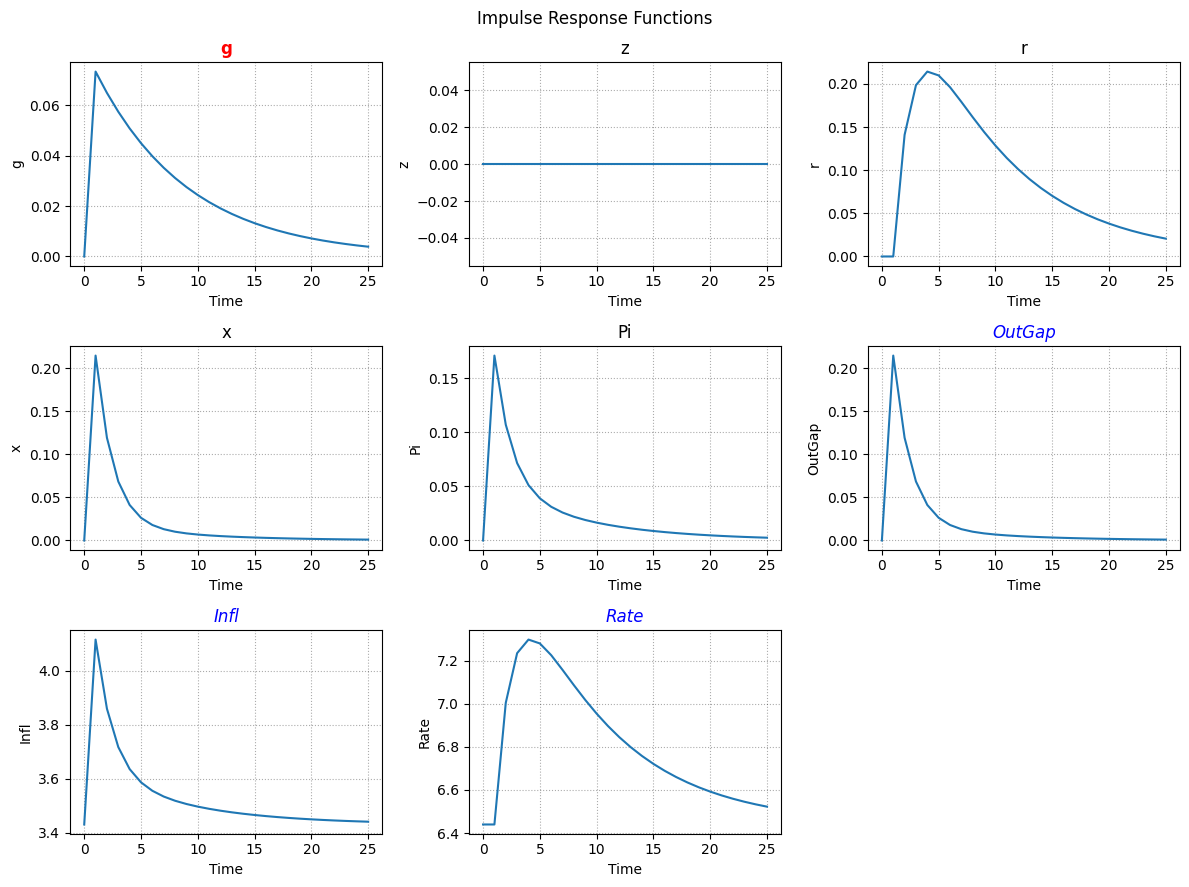

In [7]:
sol.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [8]:
kf = sol.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "linear",
    return_shocks=True,
)

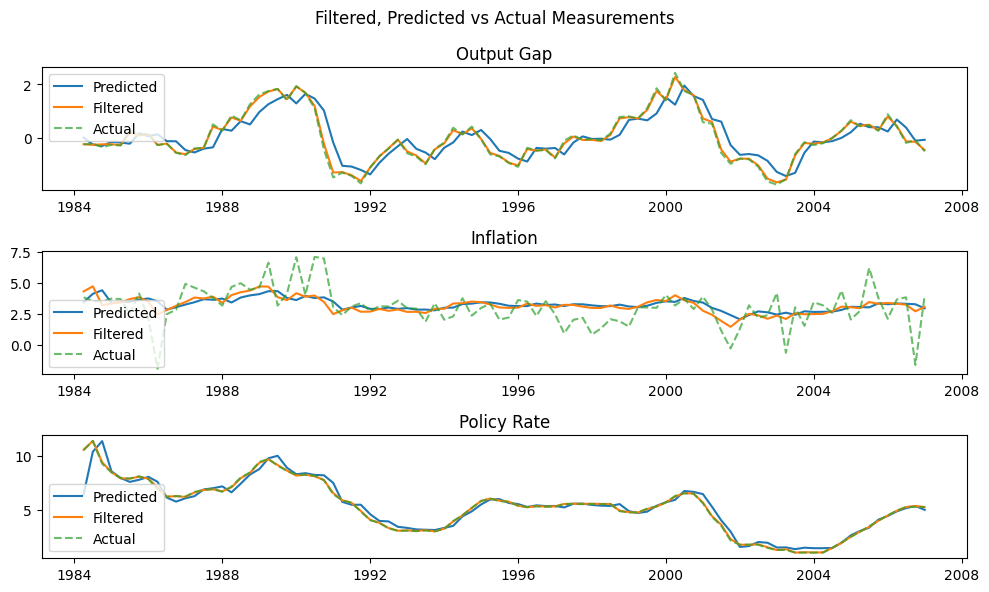

In [9]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [10]:
gz = Shock(T=len(idx) - 1, dist="norm", multivar=True, seed=0).shock_generator()
r = Shock(T=len(idx) - 1, dist="norm", seed=1).shock_generator()
sim = sol.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)

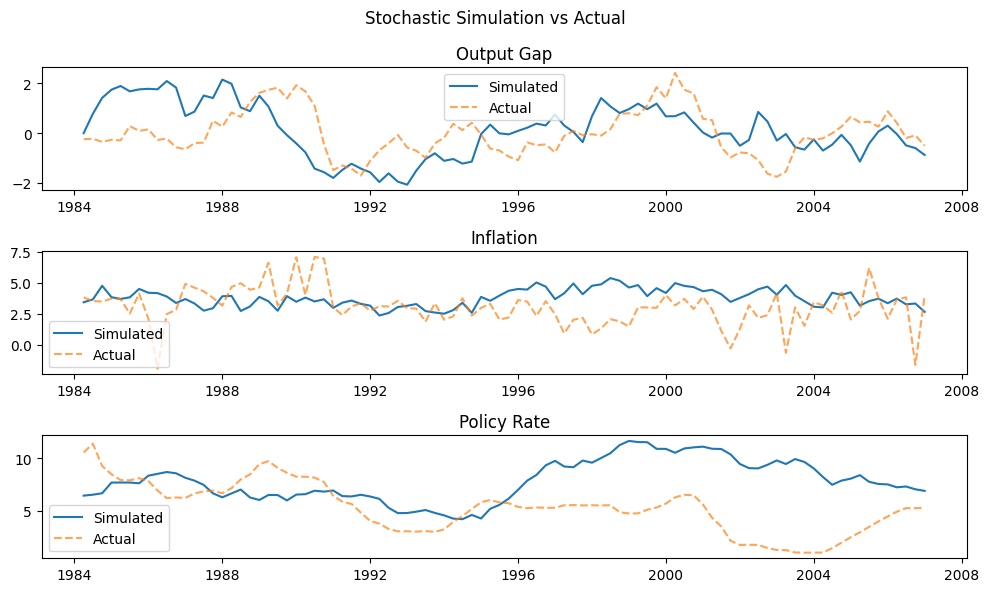

In [11]:
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Stochastic Simulation vs Actual")

ax[0].plot(idx, sim["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, sim["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

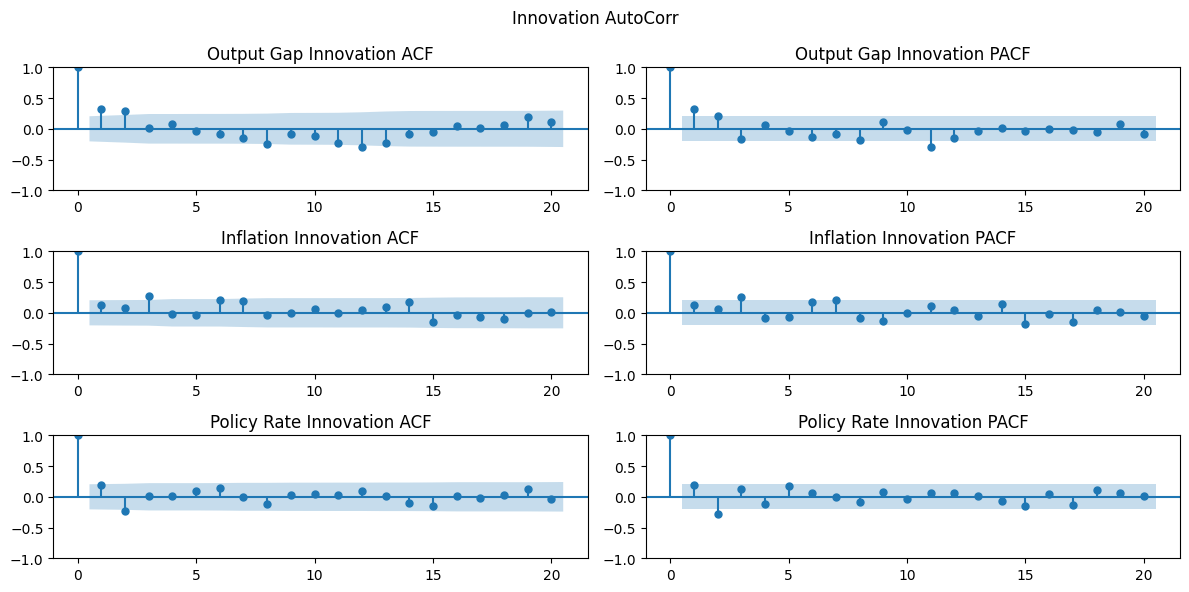

In [12]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Innovation AutoCorr")
plot_acf(
    kf.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovation ACF",
)
plot_acf(
    kf.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovation ACF",
)
plot_acf(
    kf.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovation ACF",
)
plot_pacf(
    kf.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovation PACF",
)
plot_pacf(
    kf.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovation PACF",
)
plot_pacf(
    kf.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovation PACF",
)

plt.tight_layout()

In [13]:
template = TemplateConfig(
    include_expression=False,
    interaction_form="func",
    hessian_restriction="free",
    power_law_lower_bound=2,
    power_law_upper_bound=2,
    powers_in_interactions=False,
    constant_filtering="parametrize_all",
    model_complexity_bound=20,
)

params = PySRParams(
    niterations=500,
    maxsize=20,
    complexity_of_constants=7,
    complexity_of_variables=1,
    deterministic=True,
    random_state=0,
    parallelism="serial",
    binary_operators=["+", "-", "*"],  # Avoid Div/0
)

parametrizer = ModelParametrizer(
    variable_names=["r", "Pi", "x"], params=params, config=template
)
parametrizer.add_built_in_ops()

sr_discovery = lambda obs: sol.fit_kf(
    parametrizer=parametrizer,
    y=observed.loc[observed.index >= "1984-01-01", :],
    variables=["r", "Pi", "x"],
    observable=obs,
).expressions

# Only run sr for observalbes with innovation autocorrelation.
x_sr = sr_discovery("OutGap")


# r_sr = sr_discovery("Rate")
# pi_sr = sr_discovery("Infl")

/Users/guneykiymac/Desktop/Portfolio/SymbolicDSGE/.venv/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 2.490e+05
Progress: 1580 / 15500 total iterations (10.194%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.112e-01  0.000e+00  f_1 = #3
2           2.111e-01  2.412e-04  f_1 = asinh32(#3)
4           2.086e-01  6.081e-03  f_1 = #3 * ssqrt32(#3)
6           2.053e-01  7.844e-03  f_1 = asinh32(#1) - (#1 - #3)
9           2.053e-01  4.824e-05  f_1 = #3 + (#3 - (asinh32(#1) * ssqrt32(#3)))
10          2.026e-01  1.317e-02  f_1 = (((#3 - #1) * ssqrt32(#3)) + #3) + #3
11          2.017e-01  4.322e-03  f_1 = (((#3 - asinh32(#1)) * ssqrt32(#3)) + #3) + #3
12          2.013e-01  2.253e-03  f_1 = ((#3 + (#3 + (#3 - #1))) * ssqrt32(#3)) + #3
13          1.984e-01  1.433e-02  f_1 = (#3 + #3) - (#1 * 0.31552)
15          1.971e-01  3.407e-03  f_1 = #3 + ((#

[ Info: Final population:
[ Info: Results saved to:


  - /var/folders/_8/plljqz697vd66bfjdlkc12qm0000gn/T/tmpsu2w7bww/20260323_001848_pyP6tg/hall_of_fame.csv


In [14]:
def walk_round(x, n=3):
    for atom in preorder_traversal(x):
        if isinstance(atom, Float):
            x = x.subs(atom, round(atom, n))
    return x


x_sr["initial_expr"] = x_sr["initial_expr"].apply(lambda x: walk_round(x, n=3))
x_sr[["initial_expr", "sympy_format", "loss", "complexity"]]

,initial_expr,sympy_format,loss,complexity
0,x,x,0.211186,1
1,asinh(x),asinh(x),0.211135,2
2,x**(3/2),x**_C_1,0.208582,4
3,-r + x + asinh(r),_C_1*r + x + asinh(r),0.205336,6
4,-sqrt(x)*asinh(r) + 2*x,_C_1*x + _C_2*x**_C_3*asinh(r),0.205306,9
5,sqrt(x)*(-r + x) + 2*x,_C_1*x + x**_C_2*(_C_3*r + x),0.202621,10
6,sqrt(x)*(x - asinh(r)) + 2*x,_C_1*x + x**_C_2*(_C_3*asinh(r) + x),0.201747,11
7,sqrt(x)*(-r + 3*x) + x,x + x**_C_1*(_C_2*r + _C_3*x),0.201293,12
8,-0.316*r + 2*x,_C_1*x + _C_2*r,0.198429,13
9,-0.49*r + 2.981*x,_C_1*x + _C_2*r,0.197071,15


In [15]:
# Augmented Model
parser_aug = ModelParser("../MODELS/classes/augmented.yaml")
conf_aug, kalman_aug = parser_aug.get_all()

solver_aug = DSGESolver(conf_aug, kalman_aug)
comp_aug = solver_aug.compile(n_exog=3, n_state=3)

aug = solver_aug.solve(compiled=comp_aug)  # Solve without re-estimation
parser_aug.update_calibration_parameters(
    aug.config,
    digits=3,
    output_path="../MODELS/classes/augmented.yaml",
)  # Update augmented config to reflect current parameters (same as base for now, since we haven't re-estimated yet)

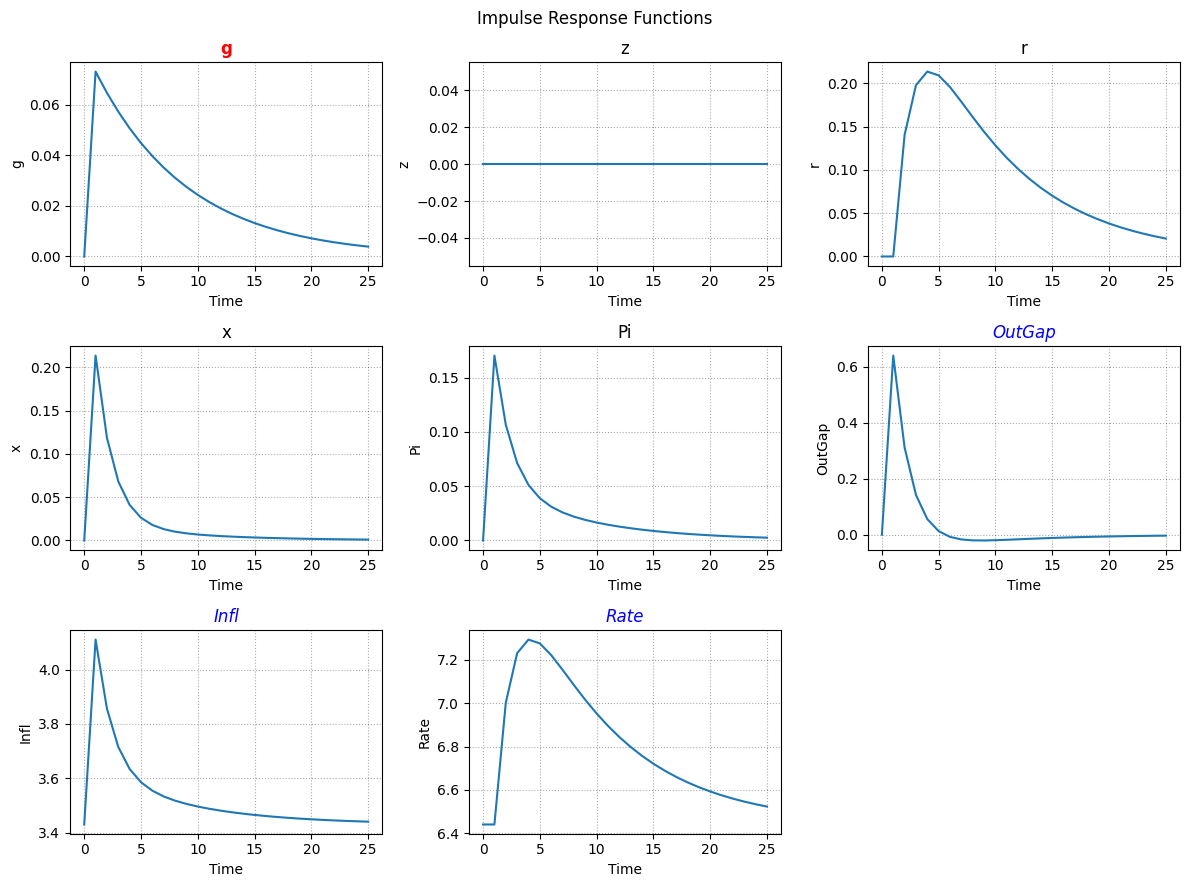

In [16]:
aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [18]:
aug.config.equations.obs_is_affine

{OutGap: False, Infl: True, Rate: True}

In [23]:
kf_aug = aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

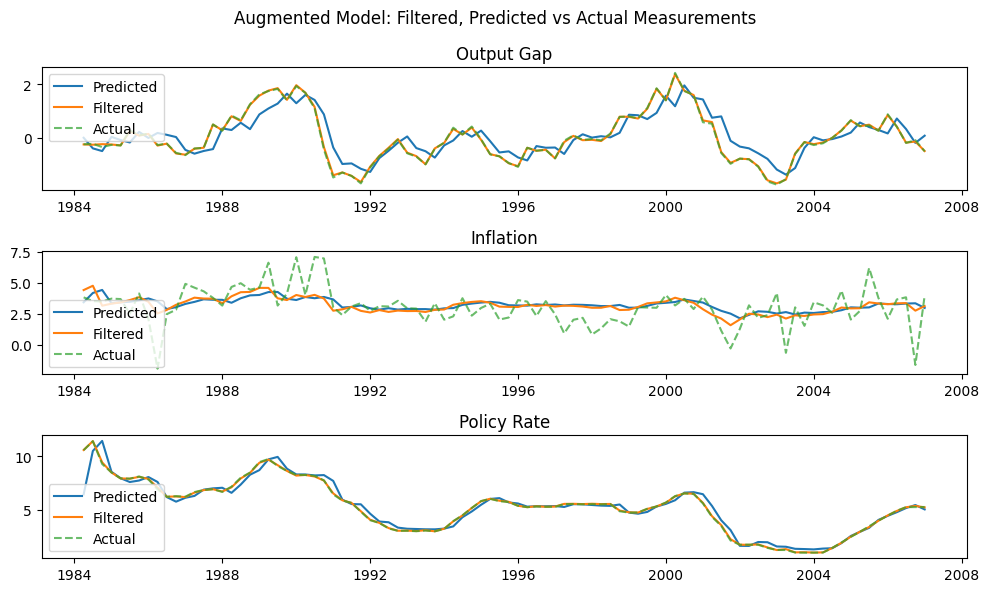

In [24]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented Model: Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_aug.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf_aug.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_aug.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf_aug.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf_aug.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf_aug.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

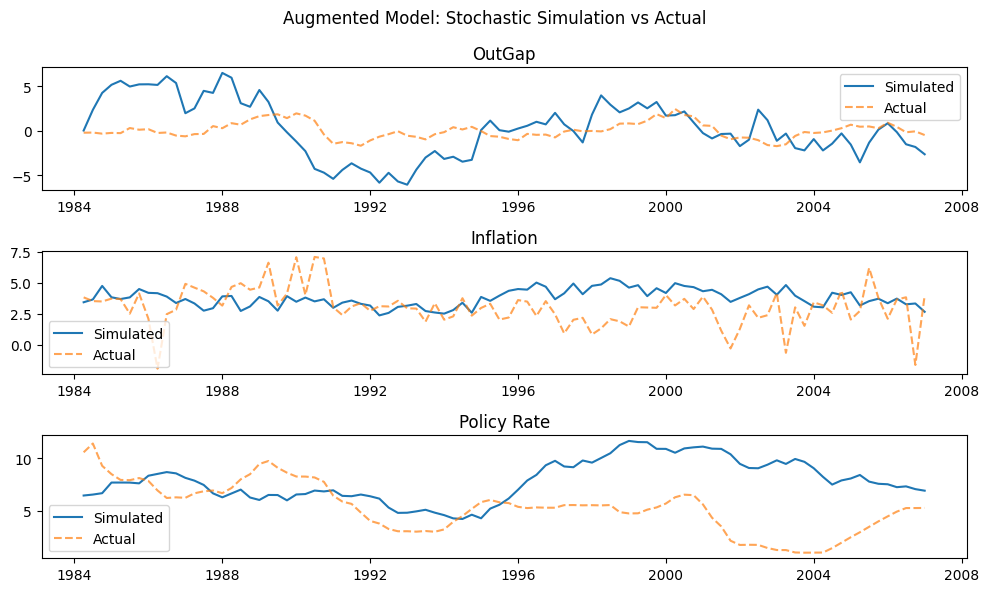

In [25]:
sim_aug = aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("OutGap")
ax[0].legend()

ax[1].plot(idx, sim_aug["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim_aug["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

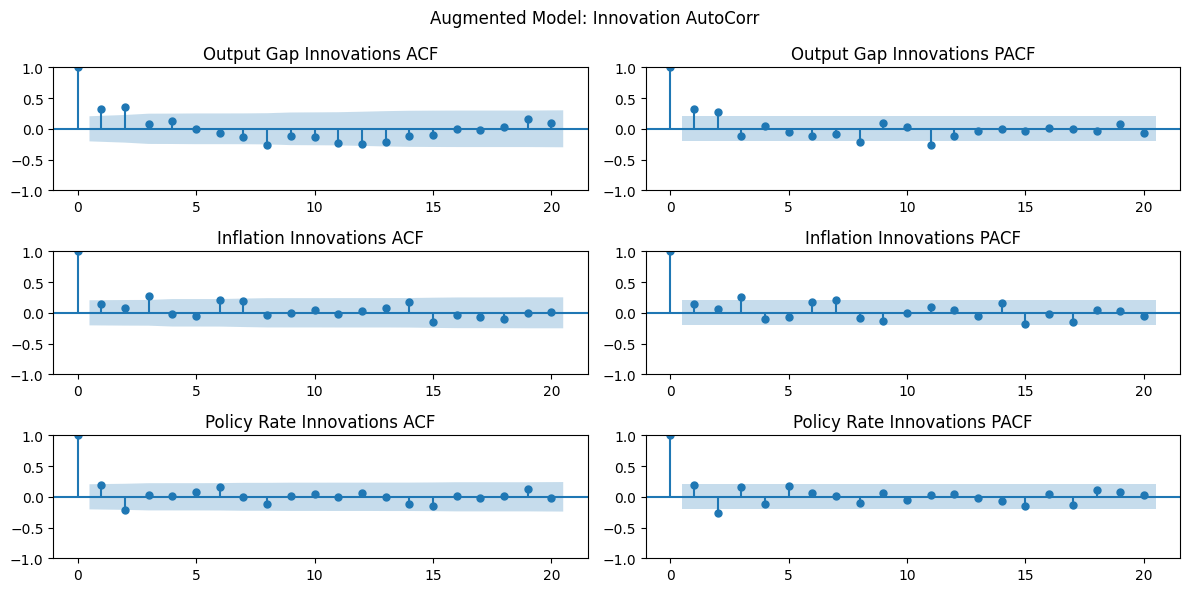

In [26]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Augmented Model: Innovation AutoCorr")

plot_acf(
    kf_aug.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovations ACF",
)
plot_acf(
    kf_aug.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovations ACF",
)
plot_acf(
    kf_aug.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovations ACF",
)
plot_pacf(
    kf_aug.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovations PACF",
)
plot_pacf(
    kf_aug.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovations PACF",
)
plot_pacf(
    kf_aug.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovations PACF",
)

plt.tight_layout()

In [27]:
# Augmented + Re-estimated model
aug_priors = {
    **prior_spec,
    **{
        "x_const": make_prior(
            "normal",
            parameters={"mean": 2.0, "std": 1.0, "random_state": next(seed)},
            transform="identity",
        ),
        "r_const": make_prior(
            "normal",
            parameters={"mean": -0.316, "std": 0.5, "random_state": next(seed)},
            transform="identity",
        ),
    },
}

res_aug, sol_aug = solver_aug.estimate_and_solve(
    compiled=comp_aug,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=aug_priors,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(aug_priors.keys()),
    n_draws=25_000,
    burn_in=10_000,
    thin=1,
)
parser_aug.update_calibration_parameters(
    sol_aug.config,
    digits=3,
    output_path="../MODELS/classes/augmented_reestimated.yaml",
)  # Store re-estimation results in a new config file

MCMC sampling concluded in 33.64 seconds with 1040.54 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [28]:
# Summarize results
param_names_aug = res_aug.param_names
post_mean_aug = np.mean(res_aug.samples, axis=0)
loglik_aug = np.mean(res_aug.logpost_trace)
accept_rate_aug = res_aug.accept_rate
pd.Series(
    {
        **dict(zip(param_names_aug, post_mean_aug)),
        "loglik": loglik_aug,
        "accept_rate": accept_rate_aug,
        "n_draws": res_aug.n_draws,
        "burn_in": res_aug.burn_in,
        "thin": res_aug.thin,
    }
)

beta               0.999376
rho_r              0.751202
rho_g              0.883314
rho_z              0.879055
psi_pi             4.745720
psi_x              0.428313
kappa              0.294709
tau_inv            0.230171
rho_gz             0.536392
sig_r              0.011778
sig_g              0.076867
sig_z              0.434139
meas_outgap        0.502549
meas_infl          0.498187
meas_rate          0.505680
meas_rho_gi        0.039830
meas_rho_gr        0.103011
meas_rho_ir       -0.051632
x_const            0.091356
r_const            0.678915
loglik          -306.645749
accept_rate        0.195600
n_draws        25000.000000
burn_in        10000.000000
thin               1.000000
dtype: float64

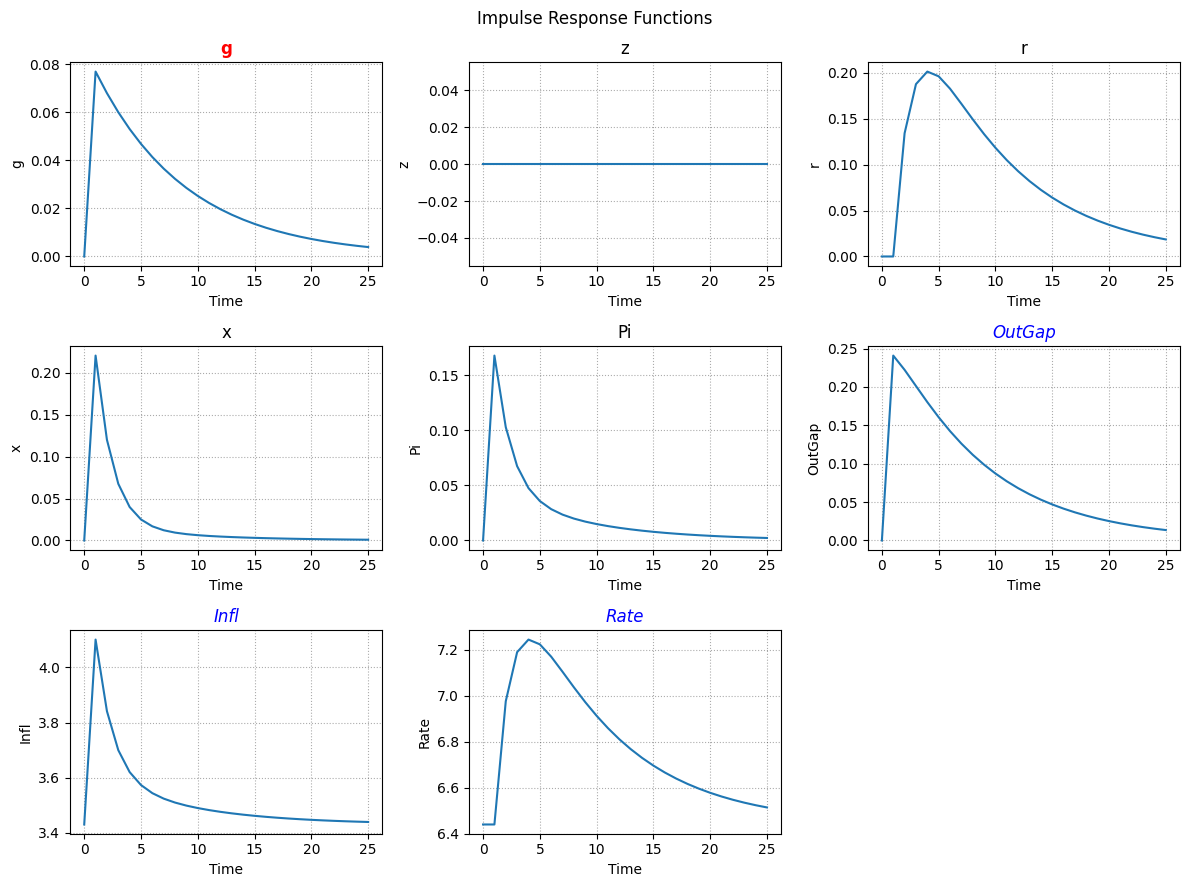

In [29]:
sol_aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [30]:
kf_aug_reest = sol_aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

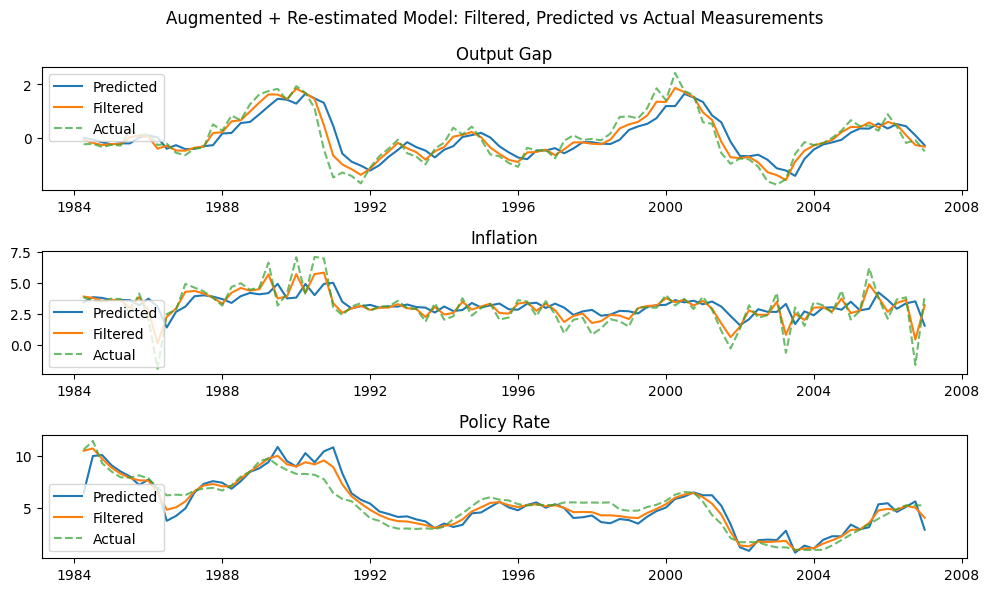

In [31]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle(
    "Augmented + Re-estimated Model: Filtered, Predicted vs Actual Measurements"
)

ax[0].plot(idx, kf_aug_reest.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf_aug_reest.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_aug_reest.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf_aug_reest.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf_aug_reest.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf_aug_reest.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

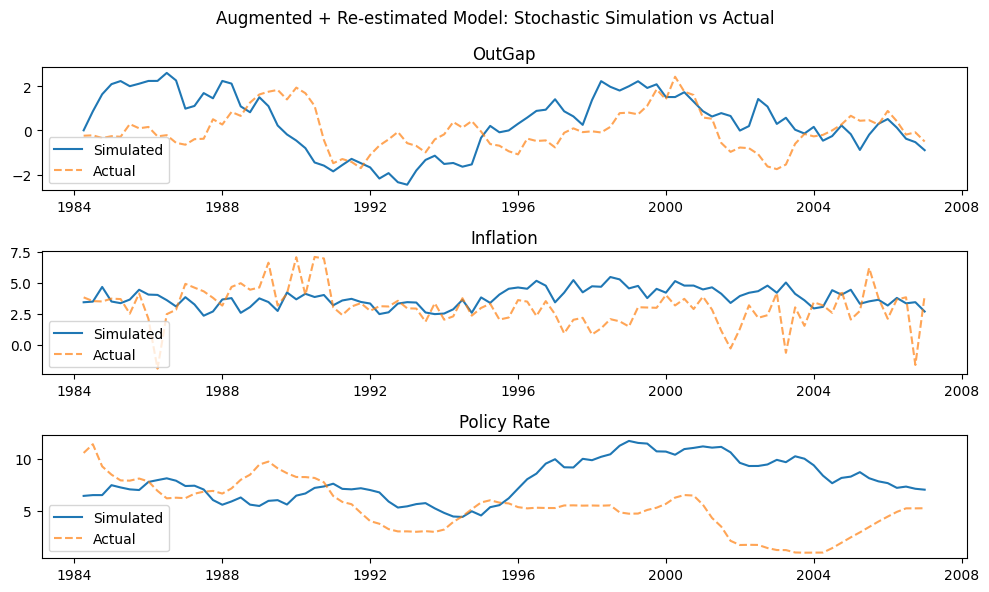

In [32]:
sim_aug_reest = sol_aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented + Re-estimated Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug_reest["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("OutGap")
ax[0].legend()

ax[1].plot(idx, sim_aug_reest["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim_aug_reest["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

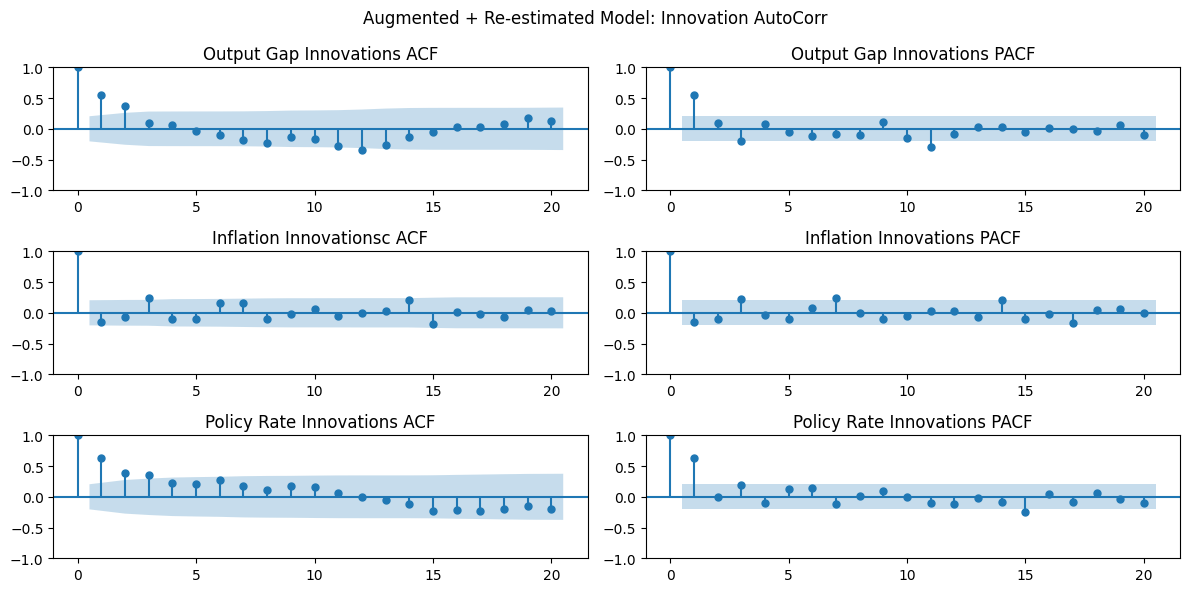

In [33]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Augmented + Re-estimated Model: Innovation AutoCorr")
plot_acf(
    kf_aug_reest.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovations ACF",
)
plot_acf(
    kf_aug_reest.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovationsc ACF",
)
plot_acf(
    kf_aug_reest.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovations ACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovations PACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovations PACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovations PACF",
)

plt.tight_layout()

In [54]:
res_aug.hpd_intervals()

{'beta': (np.float64(0.9980974986435094), np.float64(0.9999310863275153)),
 'rho_r': (np.float64(0.7566571247692176), np.float64(0.8874729384637178)),
 'rho_g': (np.float64(0.8425290983456298), np.float64(0.9163360938545002)),
 'rho_z': (np.float64(0.8292196574778231), np.float64(0.9111776098481941)),
 'psi_pi': (np.float64(1.3655692081045372), np.float64(3.2981119987624066)),
 'psi_x': (np.float64(0.19417275112263271), np.float64(0.5333129973364483)),
 'kappa': (np.float64(0.31253268837149667), np.float64(0.6363796679047323)),
 'tau_inv': (np.float64(0.7040626906454683), np.float64(1.5081410005610179)),
 'rho_gz': (np.float64(0.753565645028071), np.float64(0.9801319426898263)),
 'sig_r': (np.float64(0.02489641927720672), np.float64(0.06661003365595138)),
 'sig_g': (np.float64(0.038793508049683345), np.float64(0.08110173189918223)),
 'sig_z': (np.float64(0.34815990745126824), np.float64(0.4889675240826519)),
 'meas_outgap': (np.float64(0.311349252722754),
  np.float64(0.699552512405008